<a href="https://colab.research.google.com/github/deeksha22983/A-B_test_conversion_analysis/blob/main/Ad_vs_PSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The ad outperformed the PSA by 0.77 percentage points in conversion rate (95% CI: 0.60–0.94), a highly statistically significant result (χ² = 54.01, p < 0.001). This confirms the improvement is real, not due to chance. I recommend rolling out the ad campaign, though this analysis doesn't factor in ad spend or cost-efficiency.

In [4]:
import pandas as pd
df = pd.read_csv('marketing_AB.csv')
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20.0
1,1,1119715,ad,False,93,Tuesday,22.0
2,2,1144181,ad,False,21,Tuesday,18.0
3,3,1435133,ad,False,355,Tuesday,10.0
4,4,1015700,ad,False,276,Friday,14.0


In [5]:
df.info()
df.describe()
df['test group'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197152 entries, 0 to 197151
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     197152 non-null  int64  
 1   user id        197152 non-null  int64  
 2   test group     197152 non-null  object 
 3   converted      197152 non-null  bool   
 4   total ads      197152 non-null  int64  
 5   most ads day   197151 non-null  object 
 6   most ads hour  197151 non-null  float64
dtypes: bool(1), float64(1), int64(3), object(2)
memory usage: 9.2+ MB


,count
test group,
ad,187121
psa,10031


In [6]:
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates()


there is 0 duplicate value in the coulmn user id .

In [7]:
conversion_rates = df.groupby('test group')['converted'].mean()
print(conversion_rates)


test group
ad     0.047488
psa    0.028013
Name: converted, dtype: float64


In [8]:
from scipy.stats import chi2_contingency
import pandas as pd
contingency_table = pd.crosstab(df['test group'], df['converted'])
print(contingency_table)
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic:{chi2}")
print(f"P-value; {p_value}")

converted    False  True 
test group               
ad          178235   8886
psa           9750    281
Chi-square statistic:81.00640992970494
P-value; 2.2498672734466825e-19


In [9]:
from scipy.stats import ttest_ind
group_a= df[df['test group']=='ad']['most ads hour']
group_b = df[df['test group'] =='psa']['most ads hour']
t_stat, p_value = ttest_ind(group_a, group_b)
print(f"P-value:{p_value}")

P-value:nan


In [ ]:
print(f"Null values in 'most ads hour' for 'ad' group: {group_a.isnull().sum()}")
print(f"Null values in 'most ads hour' for 'psa' group: {group_b.isnull().sum()}")

It appears there are some null values in the `most ads hour` column for both groups. Let's remove them and re-run the t-test.

In [ ]:
group_a_clean = group_a.dropna()
group_b_clean = group_b.dropna()

t_stat_clean, p_value_clean = ttest_ind(group_a_clean, group_b_clean)

print(f"T-statistic (after dropping NaNs): {t_stat_clean}")
print(f"P-value (after dropping NaNs): {p_value_clean}")

In [10]:
import numpy as np
from scipy.stats import norm
p1= conversion_rates['ad']
p2= conversion_rates['psa']
n1= len(df[df['test group']=='ad'])
n2=len (df[df['test group']=='psa'])
diff =p1-p2
se= np.sqrt((p1*(1-p1)/n1) + (p2*(1-p2)/n2))
ci_lower = diff - 1.96 * se
ci_upper = diff + 1.96 * se
print(f"differnce inconversion rate :{diff:.4f}")
print(f"95% confidence interval : [{ci_lower:.4f}, {ci_upper:.4f}]")

differnce inconversion rate :0.0195
95% confidence interval : [0.0161, 0.0228]


much more credible than the p value


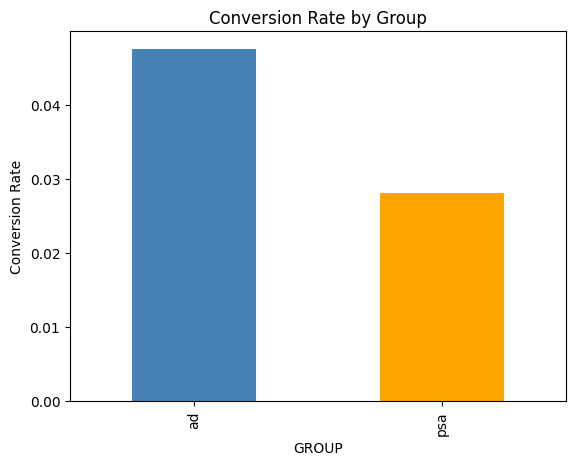

In [11]:
import matplotlib.pyplot as plt
conversion_rates.plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Conversion Rate by Group')
plt.xlabel('GROUP')
plt.ylabel('Conversion Rate')
plt.show()